# Lexis Diagrams and Person-Years: What Exactly Is the Denominator of a Rate?



---

In the [overview post](demographic-analysis-tutorial) we computed crude rates by dividing events by the *mid-year population*, and moved on quickly. This post stops at that denominator and asks the question behind every rate in this series: **a rate is events divided by exposure, but what exactly is "exposure"?**

The answer has two parts, and both are visual:

1. The **Lexis diagram**: the time × age plane on which every demographic event can be located;
2. **Person-years**: the idea that the denominator of a rate is *time lived*, not a head count.

**What you'll learn**

- How to read and draw a Lexis diagram (lifelines, period slices, cohort bands, Lexis triangles)
- Why demographers distinguish *period* from *cohort* views of the same data
- How person-years are computed, and why the mid-year population is a convenient approximation
- Why this matters for everything that follows (life tables in Lesson 1.5 are built on exactly this distinction)


---

## Part 1: The Lexis Diagram, Demography's Coordinate System

A **Lexis diagram** (after Wilhelm Lexis, 1875) plots age on the vertical axis against calendar time on the horizontal axis. Each individual is a **lifeline**: starting at birth on the horizontal axis and rising at 45° (one year of age per year of time) until death, marked with ✕.

Three ways to slice the same plane:

- a **vertical strip** = a *period* (everyone alive during calendar year $t$)
- a **diagonal band** = a *cohort* (everyone born in the same year, aging together)
- a **horizontal strip** = an *age group*

The same death can be classified by period, by cohort, or by age, and which slice you choose determines which rate you are computing.


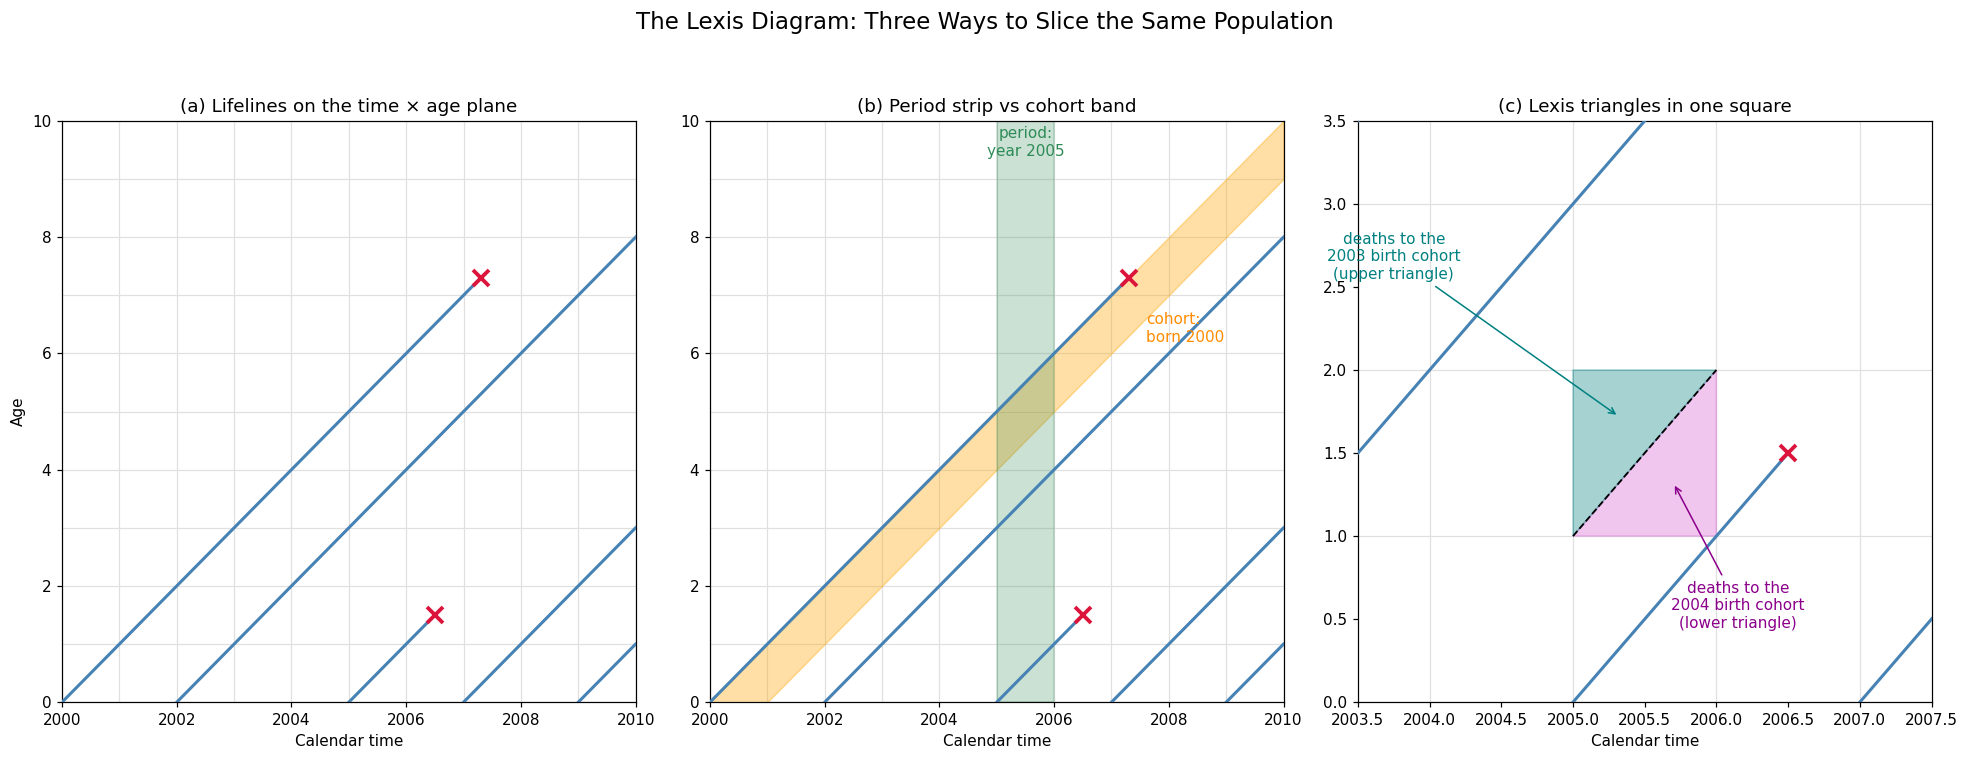

In [1]:
# ---- 1. Draw a Lexis diagram: lifelines + the three canonical slices ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# some lifelines: (birth_year, death_year or None if alive at 2010)
people = [
    (2000, 2007.3),   # dies at age 7.3
    (2002, None),
    (2005, 2006.5),   # dies at age 1.5
    (2007, None),
    (2009, None),
]
T_END = 2010

for ax in axes:
    # grid: one line per year of age and of calendar time
    for t in range(2000, T_END + 1):
        ax.axvline(t, color='0.88', lw=0.8, zorder=0)
    for a in range(0, 11):
        ax.axhline(a, color='0.88', lw=0.8, zorder=0)
    for b, d in people:
        t1 = d if d is not None else T_END
        ax.plot([b, t1], [0, t1 - b], color='steelblue', lw=2, zorder=3)
        if d is not None:
            ax.plot(d, d - b, marker='x', color='crimson', ms=10, mew=2.5, zorder=4)
    ax.set_xlim(2000, T_END); ax.set_ylim(0, 10)
    ax.set_xlabel('Calendar time')

# (a) lifelines only
axes[0].set_title('(a) Lifelines on the time × age plane')
axes[0].set_ylabel('Age')

# (b) period slice (year 2005) vs cohort slice (2000 birth cohort)
t = np.linspace(2000, T_END, 100)
axes[1].fill_between(t, t - 2000, t - 2001, color='orange', alpha=0.35, zorder=1)
axes[1].axvspan(2005, 2006, color='seagreen', alpha=0.25, zorder=1)
axes[1].text(2005.5, 9.4, 'period:\nyear 2005', ha='center', fontsize=10, color='seagreen')
axes[1].text(2007.6, 6.2, 'cohort:\nborn 2000', fontsize=10, color='darkorange')
axes[1].set_title('(b) Period strip vs cohort band')

# (c) Lexis triangles inside one age × year square
# deaths in the square [age 1–2] × [year 2005] split by birth cohort
sq = axes[2]
sq.fill([2005, 2006, 2006], [1, 2, 1], color='orchid', alpha=0.4, zorder=1)   # lower triangle: 2004 cohort
sq.fill([2005, 2005, 2006], [1, 2, 2], color='teal', alpha=0.35, zorder=1)    # upper triangle: 2003 cohort
sq.plot([2005, 2006], [1, 2], color='k', lw=1.2, ls='--', zorder=2)
sq.annotate('deaths to the\n2004 birth cohort\n(lower triangle)', xy=(2005.7, 1.32), xytext=(2006.15, 0.45),
            fontsize=10, color='darkmagenta', ha='center',
            arrowprops=dict(arrowstyle='->', color='darkmagenta'))
sq.annotate('deaths to the\n2003 birth cohort\n(upper triangle)', xy=(2005.32, 1.72), xytext=(2003.75, 2.55),
            fontsize=10, color='teal', ha='center',
            arrowprops=dict(arrowstyle='->', color='teal'))
sq.set_title('(c) Lexis triangles in one square')
sq.set_xlim(2003.5, 2007.5); sq.set_ylim(0, 3.5)

fig.suptitle('The Lexis Diagram: Three Ways to Slice the Same Population', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

Panel (c) shows why registration data need care: deaths in a single age × year square belong to **two different birth cohorts**. Children dying in the lower (purple) triangle were born in 2004 and reach exact age 1 during 2005; those in the upper (teal) triangle were born in 2003 and had already turned 1 during 2004. One quick check: pick any point in a triangle and subtract age from time; the result is the birth date. Infant mortality estimation (Lesson 1.5a, *separation factors*) depends on exactly this split.

### Period vs cohort: same plane, different questions

- **Cohort (longitudinal) view:** follow the 2000 birth cohort down its diagonal band. Genuine life-course experience, but you must wait ~100 years for the data to complete.
- **Period (cross-sectional) view:** take the vertical strip of one calendar year and treat it as if it described a *synthetic cohort* living through those rates, and it is available now. This is the view that life tables in Lesson 1.5 adopt.

Both views are legitimate; confusing them is one of the most common errors in demographic writing (we will see it again for fertility in Lesson 2.4).


---

## Part 2: Person-Years, the True Denominator of a Rate

A rate answers: *how many events per unit of exposure?* The exposure of a population is the **total time its members lived and were at risk**, measured in **person-years** (PY):

$$
M = \frac{\text{events}}{\text{person-years lived}}
$$

Person-years accumulate one-to-one with time lived: one person alive for a full year contributes 1 PY; someone who enters in July contributes 0.5; someone who dies in March contributes about 0.25, and then stops contributing. **Death removes exposure as well as life**, which is why the denominator can never be simply "the population at the start of the year."

Let's compute this from individual lifelines.


In [2]:
# ---- 2. Person-years from individual lifelines: a tiny worked example ----
# 8 people under observation during calendar year 2020 (a closed study population)
people = pd.DataFrame({
    'person': [f'P{i}' for i in range(1, 9)],
    'entry':  ['2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01',
               '2020-01-01', '2020-04-01', '2020-07-01', '2020-01-01'],
    'exit':   ['2020-03-15', '2020-12-31', '2020-12-31', '2020-12-31',
               '2020-09-30', '2020-12-31', '2020-12-31', '2020-06-30'],
    'event':  ['died', 'alive', 'alive', 'alive',
               'left study', 'alive', 'alive', 'died'],
})
people['entry'] = pd.to_datetime(people['entry'])
people['exit']  = pd.to_datetime(people['exit'])

# each person contributes exposure only while present and at risk
people['person_years'] = (people['exit'] - people['entry']).dt.days / 365.25
people['person_years'] = people['person_years'].round(2)

deaths = (people['event'] == 'died').sum()
py_total = people['person_years'].sum()
mortality_rate = deaths / py_total * 1000

print(people[['person', 'event', 'person_years']].to_string(index=False))
print(f'\nDeaths = {deaths},  Person-years = {py_total:.2f}')
print(f'Mortality rate = {deaths} / {py_total:.2f} = {mortality_rate:.1f} per 1,000 person-years')

# naive alternative, for contrast
n_initial = (people['entry'] == '2020-01-01').sum()
print(f'Naive deaths / initial headcount = {deaths}/{n_initial} = {deaths/n_initial*1000:.1f} per 1,000 (wrong: ignores mid-year entries/exits)')

person      event  person_years
    P1       died          0.20
    P2      alive          1.00
    P3      alive          1.00
    P4      alive          1.00
    P5 left study          0.75
    P6      alive          0.75
    P7      alive          0.50
    P8       died          0.50

Deaths = 2,  Person-years = 5.70
Mortality rate = 2 / 5.70 = 350.9 per 1,000 person-years
Naive deaths / initial headcount = 2/6 = 333.3 per 1,000 (wrong: ignores mid-year entries/exits)


Note what just happened:

- P1 contributed only ~0.2 PY before dying, in the denominator as well as the numerator.
- P5 (emigrated) and P6–P7 (entered late) contribute partial exposure; a head-count denominator would either miss them or overcount them.
- The resulting rate is a **death rate** ($m$, events per person-year), *not* a **probability of dying** ($q$). Keeping $m$ and $q$ apart is the whole subject of Lesson 1.4a, and converting between them ($ {}_nm_x \rightarrow {}_nq_x $) is the key step of period life-table construction in Lesson 1.5a.


---

## Part 3: The Mid-Year Population Shortcut

Exact person-years require tracking every individual, which is impossible with census-plus-registration data. The standard approximation:

$$
\text{person-years in year } t \;\approx\; \text{mid-year population} \times 1 \text{ year}
$$

**Why it works:** if the population changes roughly *linearly* over the year, person-years equal the integral of population size over the year. For linear change this integral is exactly the average of the start and end values, the mid-year value. Let's verify numerically, and also check the exponential-growth case, where demographers use a slightly different formula (Wachter §2.2):

$$
\text{PY} = \frac{N_{end} - N_{start}}{\ln N_{end} - \ln N_{start}}
$$


Linear growth:  exact PY = 1050.00,  mid-year shortcut = 1050.00
Exponential:    exact PY = 1049.21,  mid-year shortcut = 1048.81,  Wachter formula = 1049.21

Mid-year shortcut error under exponential growth: -0.04%


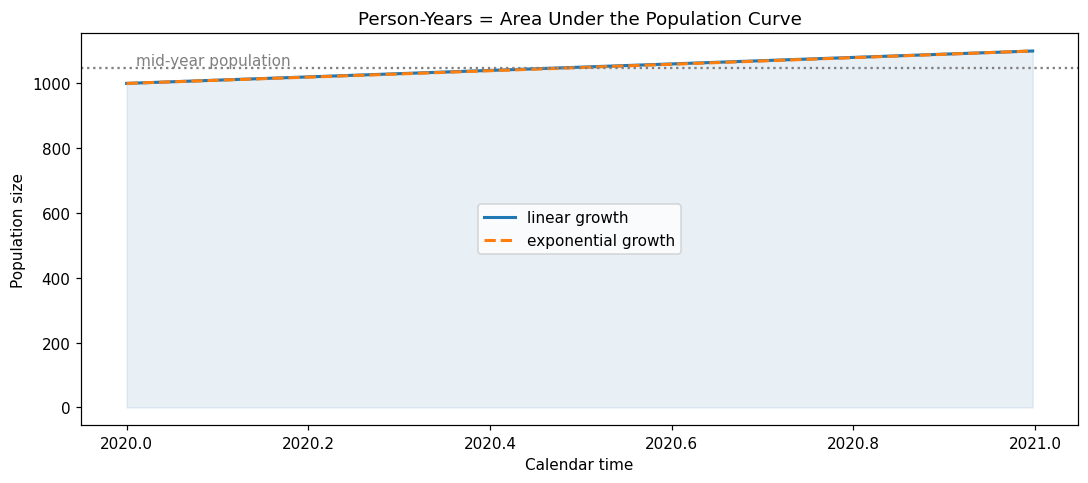

In [3]:
# ---- 3. Mid-year approximation: exact PY by daily integration vs shortcuts ----
days = np.arange(0, 365)          # integrate over the year, day by day

# case A: linear growth 1000 -> 1100 (mid-year = 1050)
N_linear = 1000 + (1100 - 1000) * days / 364
PY_exact_A = N_linear.sum() / 365          # mean daily population = person-years (per year)
PY_midyear_A = N_linear[182]
print(f'Linear growth:  exact PY = {PY_exact_A:.2f},  mid-year shortcut = {PY_midyear_A:.2f}')

# case B: exponential growth 1000 -> 1100 (r = ln(1.1))
r = np.log(1.1)
N_exp = 1000 * np.exp(r * days / 364)
PY_exact_B = N_exp.sum() / 365
PY_midyear_B = N_exp[182]
PY_formula_B = (1100 - 1000) / (np.log(1100) - np.log(1000))
print(f'Exponential:    exact PY = {PY_exact_B:.2f},  mid-year shortcut = {PY_midyear_B:.2f},  Wachter formula = {PY_formula_B:.2f}')
print(f'\nMid-year shortcut error under exponential growth: {(PY_midyear_B - PY_exact_B) / PY_exact_B * 100:+.2f}%')

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(days / 365 + 2020, N_linear, label='linear growth', lw=2)
ax.plot(days / 365 + 2020, N_exp, label='exponential growth', ls='--', lw=2)
ax.fill_between(days / 365 + 2020, N_exp, color='steelblue', alpha=0.12)
ax.axhline(PY_midyear_B, color='gray', ls=':', lw=1.5)
ax.text(2020.01, PY_midyear_B + 8, 'mid-year population', color='gray', fontsize=10)
ax.set_title('Person-Years = Area Under the Population Curve')
ax.set_xlabel('Calendar time'); ax.set_ylabel('Population size')
ax.legend()
plt.tight_layout()
plt.show()

The mid-year shortcut is exact for linear change and off by a tiny fraction under exponential growth, good enough that virtually all official statistics use it. This is what the overview post quietly did when it divided deaths by "mid-year population."

### Where the approximation can break

- **Sharp mid-year events**: a disaster, a border change, or mass displacement mid-year makes the population curve anything but smooth.
- **Strong seasonality**: tourist towns and harvest-migration regions have population curves with big within-year swings; the mid-year point need not represent the average.
- **Small sub-populations**: for single-year age groups of infants (where deaths cluster in the first weeks of life), exposure is far from uniform, and Lesson 1.5a's *separation factors* exist precisely to fix this.


---

## Part 4: Why This Post Exists

Everything in Module 1 is built on these two ideas:

| Concept introduced here | Where it returns |
|---|---|
| Lexis triangles (cohort split of deaths) | Lesson 1.5a: infant mortality & separation factors |
| Rate $m$ vs probability $q$ | Lesson 1.4a: cohort mortality; Lesson 1.5a: ${}_nm_x \rightarrow {}_nq_x$ |
| Person-years as exposure | Life-table ${}_nL_x$ column (Lesson 1.5b), literally person-years of the synthetic cohort |
| Period vs cohort | Lesson 2.4: why period TFR can "lie" (tempo distortion) |

**Exercises** (in the spirit of Carmichael's tutorials):

1. On graph paper, draw a Lexis diagram for 2015–2025, ages 0–10. Shade the band of the 2018 birth cohort and the strip of calendar year 2020. In which squares do they intersect, and which triangles of those squares belong to the cohort at ages 0, 1, 2?
2. A hospital ward had 20 beds occupied on Jan 1 and 24 on Dec 31, with occupancy growing smoothly. Approximately how many patient-days of exposure were there? What is the person-year equivalent?
3. In the 8-person example above, recompute the mortality rate *excluding* P5 (the emigrant) from both numerator and denominator. Why is that the right thing to do, and what assumption does it embody?

---

**Next post: Lesson 1.1b, The Crude Death Rate Lies.** We have an honest denominator; now we'll see why an honest numerator over an honest denominator can still mislead: two populations, identical age-specific death rates, very different crude death rates. The composition effect that motivates age standardization (Lessons 1.2–1.3).
